# Active Experimental Design under Noise and Budget Constraints

In many experiments we aim to discover how a property depends on composition or processing conditions. This is often a case for characterization by XRD, SPM, Raman etc. of spread combinatorial libraries, where a continuous range of compositions is explored on a single substrate.

A mainstream approach for automating such experiments is Bayesian optimization (BO), where a surrogate model (e.g. Gaussian process) is used to predict the property and guide the selection of the next measurement in an active, closed-loop manner.

However, classical BO typically assumes idealized conditions and does not explicitly account for key experimental constraints, such as:

- measurement noise that depends on acquisition time,
- limited experimental budget,
- and cost of moving between measurement locations.

In this challenge, the goal is to design a strategy that, using a surrogate model, decides:

- **where to measure**,
- **in what order**,
- and **for how long**,

in order to efficiently explore and recover the underlying functional dependence under these realistic conditions.

###gif_Classical BO with GP surrogate model



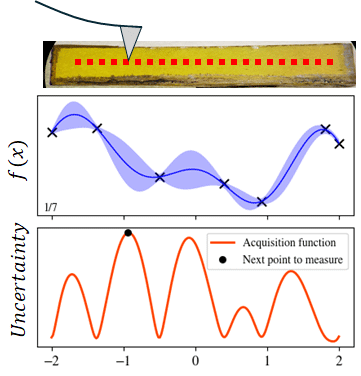

## Functions

In [24]:
!pip install gpytorch

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

In [26]:
#@title target function

# F1 — Smooth unimodal
def unimodal(x):
    x = np.asarray(x)
    res = 0.15 * (x + 2)**2 + 0.03 * (x - 1)**4
    return res/20


# F2 — Double-well
def double_well(x):
    x = np.asarray(x)
    res = 0.08 * (x**2 - 4)**2 + 0.15 * x

    return res/10


# F3 — Multimodal (Rastrigin-like, 1D)
def multimodal(x):
    x = np.asarray(x)
    res = 10 + x**2 - 7 * np.cos(2 * np.pi * x) + 9 * np.sin(1.4 * np.pi * x)
    return res/40


# F4 — Broad + narrow minima
def broad_narrow(x):
    x = np.asarray(x)

    res = (
        1
        - 1.0 * np.exp(-((x + 1.5)**2) / (2 * 0.9**2))
        - 1.6 * np.exp(-((x - 1.0)**2) / (2 * 0.18**2))
    )
    return res

In [27]:
#@title simple noise models

def noise_constant(x = None, t = None, sigma0=0.1):
    t = np.asarray(t)
    return sigma0 * np.ones_like(t, dtype=float)

def noise_decay_floor(x = None, t = None, sigma_min=0.05, A=0.18, tau=1.0):
    t = np.asarray(t)
    return sigma_min + A * np.exp(-t / tau)

In [28]:
#@title heteroskedastic_noise_model

def make_heteroskedastic_noise_model(f, xlim, n_grid=200, smooth_window=3):
    """
    Build heteroskedastic noise model on a fixed domain.

    Parameters
    ----------
    f : callable
        Ground truth function
    xlim : tuple (xmin, xmax)
        Domain of interest
    """

    xmin, xmax = xlim
    x_grid = np.linspace(xmin, xmax, n_grid)
    y_grid = f(x_grid)

    # gradient
    grad = np.abs(np.gradient(y_grid, x_grid, edge_order=2))

    # smoothing
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        half = smooth_window // 2
        grad_s = np.pad(grad, pad_width=half, mode="reflect")
        grad = np.convolve(grad_s, kernel, mode="valid")

    # normalization
    scale = np.percentile(grad, 95) + 1e-12
    grad_norm_grid = grad / scale

    def noise_model(x, t, sigma_min=0.05, sigma_max=0.5, tau=1.5):
        x = np.asarray(x, dtype=float)
        t = np.asarray(t, dtype=float)

        g = np.interp(x, x_grid, grad_norm_grid)
        sigma0_x = sigma_min + (sigma_max - sigma_min) * g

        return sigma_min + (sigma0_x - sigma_min) * np.exp(-t / tau)

    return noise_model

In [29]:
#@title measurement simulator

class MeasurementSimulator:
    def __init__(self, ground_truth_model, noise_model, rng=None, **noise_kwargs):
        """
        Parameters
        ----------
        ground_truth_model : callable
            Function f(x)
        noise_model : callable
            Function sigma(x, t, **noise_kwargs)
        rng : None, int, or np.random.Generator
            Random generator or seed
        **noise_kwargs
            Default parameters for noise_model
        """
        self.f = ground_truth_model
        self.noise_model = noise_model
        self.noise_kwargs = noise_kwargs

        if rng is None:
            self.rng = np.random.default_rng()
        elif isinstance(rng, (int, np.integer)):
            self.rng = np.random.default_rng(rng)
        else:
            self.rng = rng

    def measure(self, coords, **noise_kwargs):
        """
        coords : array of shape (N, 2)
            Columns are (x, t)

        Returns
        -------
        y_meas : array of shape (N,)
            Noisy measurements
        """
        coords = np.asarray(coords, dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2:
            raise ValueError("coords must have shape (N, 2)")

        x = coords[:, 0]
        t = coords[:, 1]

        kwargs = {**self.noise_kwargs, **noise_kwargs}
        sigma = np.asarray(self.noise_model(x, t, **kwargs), dtype=float)
        noise = self.rng.normal(0.0, sigma, size=len(x))

        return self.f(x) + noise

    __call__ = measure

In [30]:
#@title gp functions

import torch
import gpytorch


def gp_predict(x_train, y_train, x_test, training_iter=100, lr=0.1):
    """
    Fit GP on (x_train, y_train) and predict on x_test.

    Parameters
    ----------
    x_train : array-like (N,)
    y_train : array-like (N,)
    x_test  : array-like (M,)

    Returns
    -------
    mean : (M,)
    std  : (M,)
    """

    # convert to torch
    x_train = torch.as_tensor(x_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.float32)
    x_test  = torch.as_tensor(x_test, dtype=torch.float32)

    # ensure 2D inputs
    if x_train.ndim == 1:
        x_train = x_train.unsqueeze(-1)
    if x_test.ndim == 1:
        x_test = x_test.unsqueeze(-1)

    # define model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()

    class GPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super().__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel()
            )

        def forward(self, x):
            mean = self.mean_module(x)
            covar = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean, covar)

    model = GPModel(x_train, y_train, likelihood)

    # train
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for _ in range(training_iter):
        optimizer.zero_grad()
        output = model(x_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()

    # predict
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        pred = likelihood(model(x_test))
        mean = pred.mean.cpu().numpy()
        std = pred.stddev.cpu().numpy()

    return mean, std

In [31]:
#@title cost models

def travel_cost(dx, speed=0.5) -> float:
  return abs(dx) / speed


## Introduction

In [32]:
x = np.linspace(-4,4,100) #spatial coordinate (compositional/parameter space)
t = np.linspace(0,10,100) #acquisition time

We suggest selecting one of the following four “ground truth” functions to represent the underlying functionality.

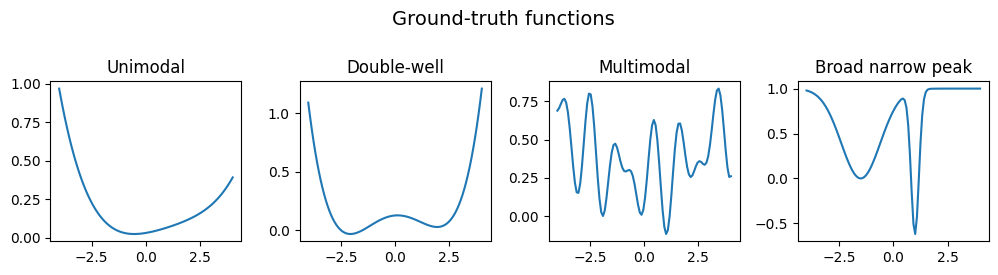

In [33]:
#ground truth functions
fig, ax = plt.subplots(1,4, figsize=(10, 2.7))

ax[0].plot(x, unimodal(x))
ax[1].plot(x, double_well(x))
ax[2].plot(x, multimodal(x))
ax[3].plot(x, broad_narrow(x))

ax[0].set_title('Unimodal')
ax[1].set_title('Double-well')
ax[2].set_title('Multimodal')
ax[3].set_title('Broad narrow peak')

fig.suptitle('Ground-truth functions', y=1, fontsize=14)

plt.tight_layout()

To emulate noisy measurements, we consider two homoscedastic noise models. The first is a **constant noise** model (trivial case), where the measurement precision is independent of acquisition time. The second is a **decaying noise** model, where the noise decreases exponentially with acquisition time and approaches a maximum achievable precision.

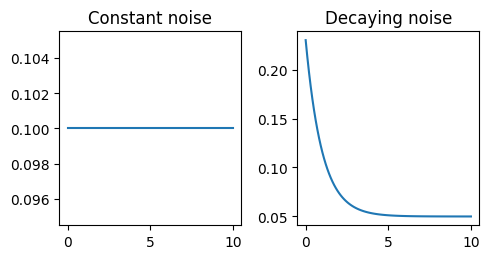

In [34]:
#homoskedastic noise model

fig, ax = plt.subplots(1,2, figsize=(5, 2.7))

ax[0].plot(t, noise_constant(x, t))
ax[0].set_title('Constant noise')
ax[1].plot(t, noise_decay_floor(x, t))
ax[1].set_title('Decaying noise')

plt.tight_layout()

For those seeking more hardcore challenge, we also suggest a **heteroscedastic noise model**, where the measurement noise depends on the location. In our specific case, the noise level is proportional to the local gradient of the underlying function, while still decaying with acquisition time toward a limiting precision.

Text(0.5, 0.98, 'Heteroskedastic noise model')

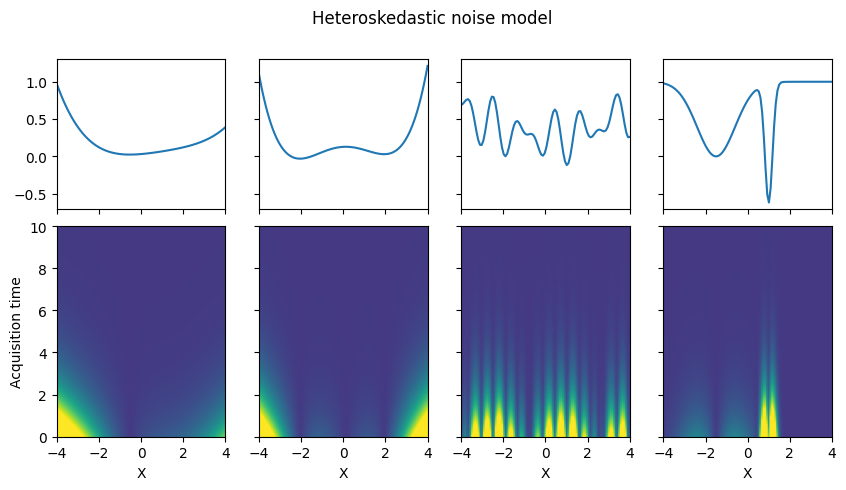

In [35]:
#@title heteroskedastic noise model

funcs = [unimodal, double_well, multimodal, broad_narrow]

fig, ax = plt.subplots(2, 4, figsize=(10, 5),
                       height_ratios=(1,1.5),
                       sharex=True,
                       sharey='row',
                       gridspec_kw={'hspace': 0.05})

for i,ax0_ in enumerate(ax[0]):
  ax0_.plot(x, funcs[i](x))

for i,ax1_ in enumerate(ax[1]):
  noise_model = make_heteroskedastic_noise_model(funcs[i], (-4, 4))
  ax1_.imshow(noise_model(x, t.reshape(-1,1)),
              origin='lower',
              extent=[x.min(), x.max(), t.min(), t.max()],
              vmax=.3, vmin=0)
  ax1_.set_xlabel('X')

ax[1,0].set_ylabel('Acquisition time')

fig.suptitle('Heteroskedastic noise model')


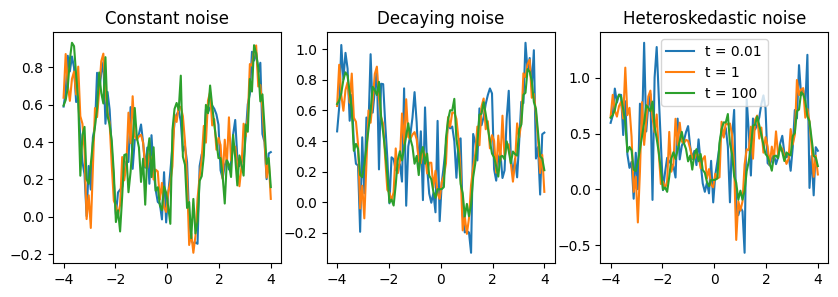

In [36]:
#@title example: grid measurements with different acqusition time

x = np.linspace(-4,4, 100) #x grid

durations = [0.01, 1, 100] #select durations
model = multimodal #select model [unimodal, double_well, multimodal, broad_narrow]

noise_heter_model = make_heteroskedastic_noise_model(model, (-4, 4))

sim_const = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_constant,
    rng=123,
)

sim_decay = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_decay_floor,
    rng=123,
)

sim_heterosk = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_heter_model,
    rng=123,
)

fig, ax = plt.subplots(1, 3, figsize=(10,3))

for d in durations:
  d_ar = np.ones(len(x))*d
  coords = np.vstack([x, d_ar]).T

  ax[0].plot(coords[:,0], sim_const.measure(coords), label = f't = {d}')
  ax[1].plot(coords[:,0], sim_decay.measure(coords), label = f't = {d}')
  ax[2].plot(coords[:,0], sim_heterosk.measure(coords), label = f't = {d}')

ax[0].set_title('Constant noise')
ax[1].set_title('Decaying noise')
ax[2].set_title('Heteroskedastic noise')
ax[2].legend()

In [37]:
#@title example: surrogate modeling

#homoskedatic noise model: [noise_constant, noise_decay_floor]
#ground truth models: [unimodal, double_well, multimodal, broad_narrow]


#If we select the heteroskedastic noise model, we first need to construct it. For the homoskedastic cases, the models are already defined.
noise_heter_model = make_heteroskedastic_noise_model(double_well, xlim=(-4, 4)) #please define the x range

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well,
    noise_model=noise_heter_model,
    rng=123,
)

In [38]:

#define x_grid on the explored interval

x_grid = np.linspace(-4, 4, 500)

# For this example, select 4 random locations in the range (-4, 4)
x = np.random.random(7) * 8 - 4

# Set acquisition time (t = 3) for all locations
t = np.ones(len(x)) * 1

# Form the coordinate array: [[x1, t1], [x2, t2], ...]
coords = np.column_stack([x, t])

#make "measurements"
y = meas_sim.measure(coords)

#surrogate modeling
mean, std = gp_predict(x, y, x_grid, training_iter=100, lr=0.1)

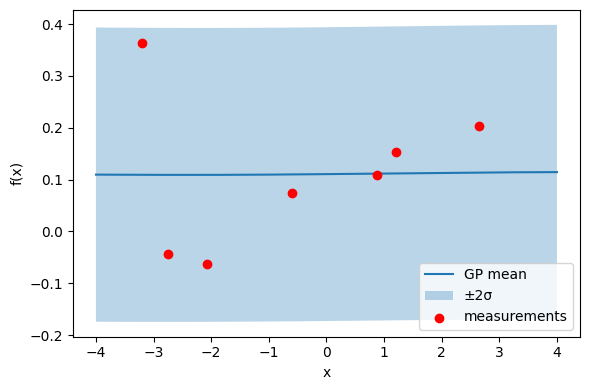

In [39]:
plt.figure(figsize=(6, 4))

# GP mean
plt.plot(x_grid, mean, label="GP mean")

# uncertainty band
plt.fill_between(
  x_grid,
  mean - 2 * std,
  mean + 2 * std,
  alpha=0.3,
  label="±2σ"
)

# training points
plt.scatter(x, y, color="red", zorder=3, label="measurements")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()

For simplicity, we treat time as the cost function. The cost of a single measurement is therefore equal to its acquisition time. In addition, we introduce a travel cost, which accounts for moving between measurement locations and is assumed to be proportional to the distance between them.

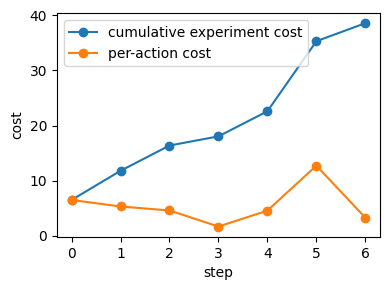

In [40]:
#@title total experiment cost

# initial position
x0 = 0

# displacement between consecutive points (including first move from x0)
dx = x - np.append(x0, x[:-1])

# cost of each action = travel cost + acquisition time
action_costs = travel_cost(dx) + t

# visualize costs
fig = plt.figure(figsize=(4,3))
plt.plot(np.cumsum(action_costs), 'o-', label='cumulative experiment cost')
plt.plot(action_costs, 'o-', label='per-action cost')

plt.xlabel('step')
plt.ylabel('cost')
plt.legend()
plt.tight_layout()




---


## Final
---



### Part I

Part I. First, let's make sure that there is indeed a problem. Assume that total experimental time is 80, an dmoving form one location to another takes 5 time units (and does not depend on the measurement distance). Here, if we do measurement with just one location, we have low noise, but we definitely have not learned ur function f(x). At the same time, if we do measurement at 16 locations, all out time is spent moving. So the optimum is somewhere between.

You are free to choose the ground truth function and noise model (decaying or heteroskedastic, use constant noise only for benchmarking if needed).

In [41]:
B = 80 #your budget (can be different)

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well, #choose gt function
    noise_model=noise_decay_floor,  #choose noise model
    rng=123,
)

I.1. First, experiment with the simple gird search. Let's assume that we run measurements at N = 1, 2, 3, .. , 16 points. How does MSE error and predictive uncertaity change with N? WHat is optimal time?

PART I.1 — Grid Search  (uniform spacing, varying N)
  N   t_meas   travel         MSE     MeanStd
----------------------------------------------------------
  1    80.00      0.0  N/A (1 pt)      0.0500
  2    37.50      5.0     1.02804      0.1005
  3    23.33     10.0     0.43576      0.4601
  4    16.25     15.0     0.16752      0.5267
  5    12.00     20.0     0.10213      0.5578
  6     9.17     25.0     0.07770      0.4758
  7     7.14     30.0     0.06678      0.4726
  8     5.62     35.0     0.00896      0.3607
  9     4.44     40.0     0.00952      0.2034
 10     3.50     45.0     0.00205      0.1189
 11     2.73     50.0     0.00261      0.0791
 12     2.08     55.0     0.00316      0.0770
 13     1.54     60.0     0.00359      0.0760
 14     1.07     65.0     0.00576      0.1926
 15     0.67     70.0     0.02141      0.2289
 16     0.31     75.0     0.01095      0.2163

>>> Optimal N (min MSE) = 10



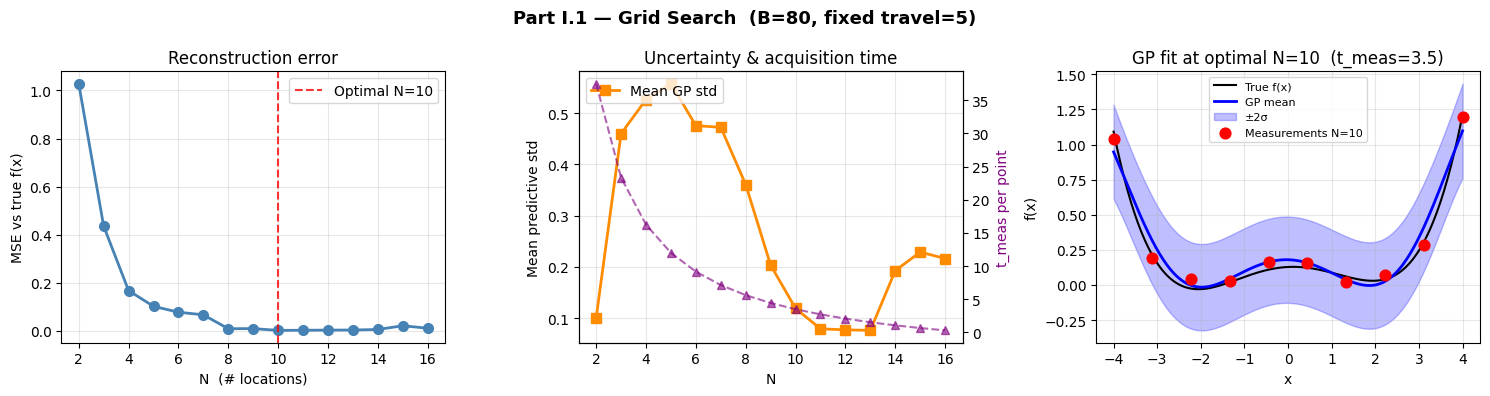

In [42]:
TRAVEL_FIXED = 5
XLIM = (-4, 4)
X_EVAL = np.linspace(XLIM[0], XLIM[1], 300)
F_TRUE = double_well(X_EVAL)

print("=" * 58)
print("PART I.1 — Grid Search  (uniform spacing, varying N)")
print("=" * 58)
print(f"{'N':>3}  {'t_meas':>7}  {'travel':>7}  {'MSE':>10}  {'MeanStd':>10}")
print("-" * 58)

grid_Ns, grid_mse, grid_unc, grid_tmeas = [], [], [], []

for N in range(1, 17):
    travel    = TRAVEL_FIXED * (N - 1)
    remaining = B - travel

    if remaining <= 0:
        print(f"{N:>3}  {'—':>7}  {travel:>7.1f}  {'budget exhausted':>22}")
        grid_Ns.append(N); grid_mse.append(np.nan)
        grid_unc.append(np.nan); grid_tmeas.append(0)
        continue

    t_meas = remaining / N
    x_locs = np.linspace(*XLIM, N)
    coords = np.column_stack([x_locs, np.full(N, t_meas)])
    y_meas = meas_sim.measure(coords)

    if N == 1:
        sigma = noise_decay_floor(t=np.array([t_meas]))[0]
        grid_Ns.append(N); grid_mse.append(np.nan)
        grid_unc.append(sigma); grid_tmeas.append(t_meas)
        print(f"{N:>3}  {t_meas:>7.2f}  {travel:>7.1f}  "
              f"{'N/A (1 pt)':>10}  {sigma:>10.4f}")
        continue

    mean, std = gp_predict(x_locs, y_meas, X_EVAL)
    mse  = np.mean((mean - F_TRUE)**2)
    munc = np.mean(std)
    grid_Ns.append(N); grid_mse.append(mse)
    grid_unc.append(munc); grid_tmeas.append(t_meas)
    print(f"{N:>3}  {t_meas:>7.2f}  {travel:>7.1f}  {mse:>10.5f}  {munc:>10.4f}")

best_N_grid = grid_Ns[np.nanargmin(grid_mse)]
print(f"\n>>> Optimal N (min MSE) = {best_N_grid}\n")

valid = [not np.isnan(m) for m in grid_mse]
vNs  = [grid_Ns[i]    for i in range(len(grid_Ns))    if valid[i]]
vMSE = [grid_mse[i]   for i in range(len(grid_mse))   if valid[i]]
vUnc = [grid_unc[i]   for i in range(len(grid_unc))   if valid[i]]
vTm  = [grid_tmeas[i] for i in range(len(grid_tmeas)) if valid[i]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Part I.1 — Grid Search  (B=80, fixed travel=5)", fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(vNs, vMSE, 'o-', color='steelblue', lw=2, ms=7)
ax.axvline(best_N_grid, color='red', ls='--', alpha=0.8, label=f'Optimal N={best_N_grid}')
ax.set_xlabel('N  (# locations)'); ax.set_ylabel('MSE vs true f(x)')
ax.set_title('Reconstruction error'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(vNs, vUnc, 's-', color='darkorange', lw=2, ms=7, label='Mean GP std')
ax2r = ax.twinx()
ax2r.plot(vNs, vTm, '^--', color='purple', alpha=0.6, ms=6, label='t_meas')
ax2r.set_ylabel('t_meas per point', color='purple')
ax.set_xlabel('N'); ax.set_ylabel('Mean predictive std')
ax.set_title('Uncertainty & acquisition time'); ax.legend(loc='upper left'); ax.grid(alpha=0.3)

ax = axes[2]
N_opt  = best_N_grid
t_opt  = grid_tmeas[grid_Ns.index(N_opt)]
x_opt  = np.linspace(*XLIM, N_opt)
sim_   = MeasurementSimulator(double_well, noise_decay_floor, rng=123)
y_opt  = sim_.measure(np.column_stack([x_opt, np.full(N_opt, t_opt)]))
m_, s_ = gp_predict(x_opt, y_opt, X_EVAL)
ax.plot(X_EVAL, F_TRUE, 'k-', lw=1.5, label='True f(x)')
ax.plot(X_EVAL, m_,     'b-', lw=2,   label='GP mean')
ax.fill_between(X_EVAL, m_-2*s_, m_+2*s_, alpha=0.25, color='blue', label='±2σ')
ax.scatter(x_opt, y_opt, color='red', zorder=5, s=60, label=f'Measurements N={N_opt}')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'GP fit at optimal N={N_opt}  (t_meas={t_opt:.1f})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The optimal number of locations is $N = 6$. With a fixed travel cost of 5, moving 5 times costs 25 units. This leaves 55 budget units for measuring, which results in an optimal measurement time of $t_{meas} \approx 9.17$ per location

I.2. Now let's assume that you run this as a Bayesian Optimization cycle for fixed duration. Make the same estimate

PART I.2 — BO with fixed travel cost
  N   t_meas         MSE     MeanStd
----------------------------------------------------------
  1    80.00         N/A      0.0500
  2    37.50     0.23013      0.0643
  3    23.33     0.09975      0.2318
  4    16.25     0.05909      0.1592
  5    12.00     0.07222      0.2527
  6     9.17     0.06931      0.2484
  7     7.14     0.06808      0.2460
  8     5.62     0.06375      0.2271
  9     4.44     0.05211      0.1884
 10     3.50     0.06400      0.2106
 11     2.73     0.00190      0.0505
 12     2.08     0.00978      0.1969
 13     1.54     0.00576      0.0974
 14     1.07     0.01054      0.1907
 15     0.67     0.01152      0.1794
 16     0.31     0.01250      0.2575

>>> Optimal N (min MSE) = 11



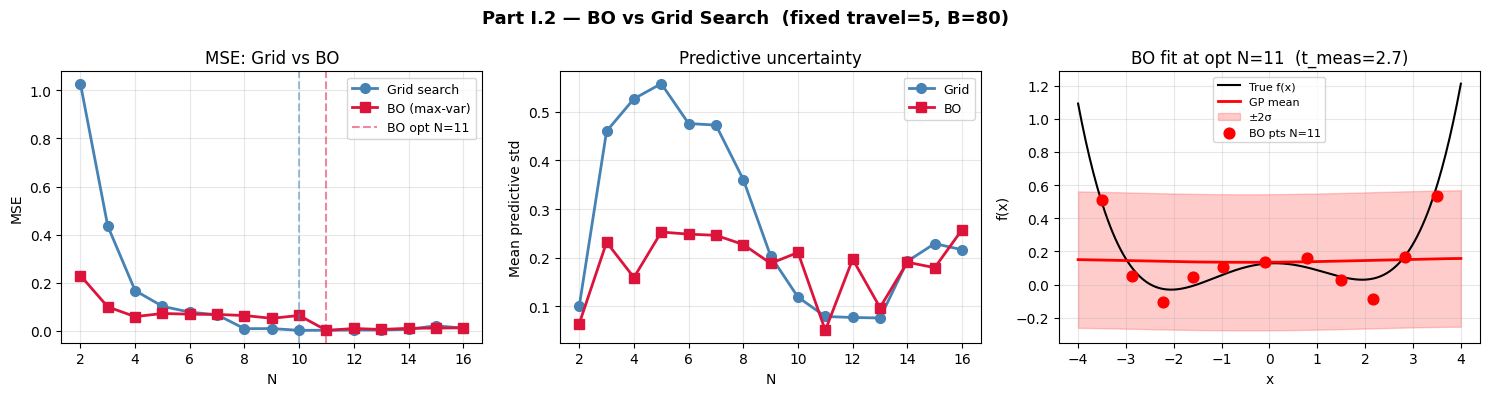

In [43]:
def run_bo_fixed_travel(N, seed=42):
    travel    = TRAVEL_FIXED * (N - 1)
    remaining = B - travel
    if remaining <= 0 or N == 0:
        return np.nan, np.nan, 0
    t_meas = remaining / N

    if N == 1:
        sigma = noise_decay_floor(t=np.array([t_meas]))[0]
        return np.nan, sigma, t_meas

    x_all = np.array([-3.5, 3.5])
    y_all = meas_sim.measure(np.column_stack([x_all, np.full(2, t_meas)]))

    for _ in range(2, N):
        _, std_p = gp_predict(x_all, y_all, X_EVAL)
        scores = std_p.copy()
        for xi in x_all:
            scores *= (1 - np.exp(-0.5 * ((X_EVAL - xi) / 0.3)**2))
        x_next = X_EVAL[np.argmax(scores)]
        y_next = meas_sim.measure(np.array([[x_next, t_meas]]))
        x_all  = np.append(x_all, x_next)
        y_all  = np.append(y_all, y_next[0])

    mean, std = gp_predict(x_all, y_all, X_EVAL)
    return np.mean((mean - F_TRUE)**2), np.mean(std), t_meas


print("=" * 58)
print("PART I.2 — BO with fixed travel cost")
print("=" * 58)
print(f"{'N':>3}  {'t_meas':>7}  {'MSE':>10}  {'MeanStd':>10}")
print("-" * 58)

bo_Ns, bo_mse, bo_unc = [], [], []
for N in range(1, 17):
    mse, unc, tm = run_bo_fixed_travel(N)
    bo_Ns.append(N); bo_mse.append(mse); bo_unc.append(unc)
    mse_str = f"{mse:.5f}" if not np.isnan(mse) else "N/A"
    print(f"{N:>3}  {tm:>7.2f}  {mse_str:>10}  {unc:>10.4f}")

best_N_bo = bo_Ns[np.nanargmin(bo_mse)]
print(f"\n>>> Optimal N (min MSE) = {best_N_bo}\n")

vbo   = [not np.isnan(m) for m in bo_mse]
boNv  = [bo_Ns[i]  for i in range(len(bo_Ns))  if vbo[i]]
boMv  = [bo_mse[i] for i in range(len(bo_mse)) if vbo[i]]
boUv  = [bo_unc[i] for i in range(len(bo_unc)) if vbo[i]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Part I.2 — BO vs Grid Search  (fixed travel=5, B=80)",
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(vNs,  vMSE, 'o-', color='steelblue', lw=2, ms=7, label='Grid search')
ax.plot(boNv, boMv, 's-', color='crimson',   lw=2, ms=7, label='BO (max-var)')
ax.axvline(best_N_grid, color='steelblue', ls='--', alpha=0.5)
ax.axvline(best_N_bo,   color='crimson',   ls='--', alpha=0.5,
           label=f'BO opt N={best_N_bo}')
ax.set_xlabel('N'); ax.set_ylabel('MSE'); ax.set_title('MSE: Grid vs BO')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(vNs,  vUnc, 'o-', color='steelblue', lw=2, ms=7, label='Grid')
ax.plot(boNv, boUv, 's-', color='crimson',   lw=2, ms=7, label='BO')
ax.set_xlabel('N'); ax.set_ylabel('Mean predictive std')
ax.set_title('Predictive uncertainty'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[2]
N_bo_opt = best_N_bo
tm_bo    = (B - TRAVEL_FIXED*(N_bo_opt-1)) / N_bo_opt
sim2     = MeasurementSimulator(double_well, noise_decay_floor, rng=42)
xbo = np.array([-3.5, 3.5])
ybo = sim2.measure(np.column_stack([xbo, np.full(2, tm_bo)]))
for _ in range(2, N_bo_opt):
    _, sp = gp_predict(xbo, ybo, X_EVAL)
    sc = sp.copy()
    for xi in xbo:
        sc *= (1 - np.exp(-0.5 * ((X_EVAL - xi) / 0.3)**2))
    xn = X_EVAL[np.argmax(sc)]
    yn = sim2.measure(np.array([[xn, tm_bo]]))
    xbo = np.append(xbo, xn); ybo = np.append(ybo, yn[0])
mbo, sbo = gp_predict(xbo, ybo, X_EVAL)
ax.plot(X_EVAL, F_TRUE, 'k-', lw=1.5, label='True f(x)')
ax.plot(X_EVAL, mbo,    'r-', lw=2,   label='GP mean')
ax.fill_between(X_EVAL, mbo-2*sbo, mbo+2*sbo, alpha=0.2, color='red', label='±2σ')
ax.scatter(xbo, ybo, color='red', s=60, zorder=5, label=f'BO pts N={N_bo_opt}')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'BO fit at opt N={N_bo_opt}  (t_meas={tm_bo:.1f})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

I.3. Now asusme that the cost of mocing is proportional to the travelled length. Explore how BO works in this case.

PART I.3 — BO with proportional travel cost
  speed = 0.5  →  full domain (8 units) costs 16 time units
  t_meas=1.0  →  11 measurements,  final MSE = 0.02224
  t_meas=3.0  →  8 measurements,  final MSE = 0.02305
  t_meas=6.0  →  6 measurements,  final MSE = 0.05196


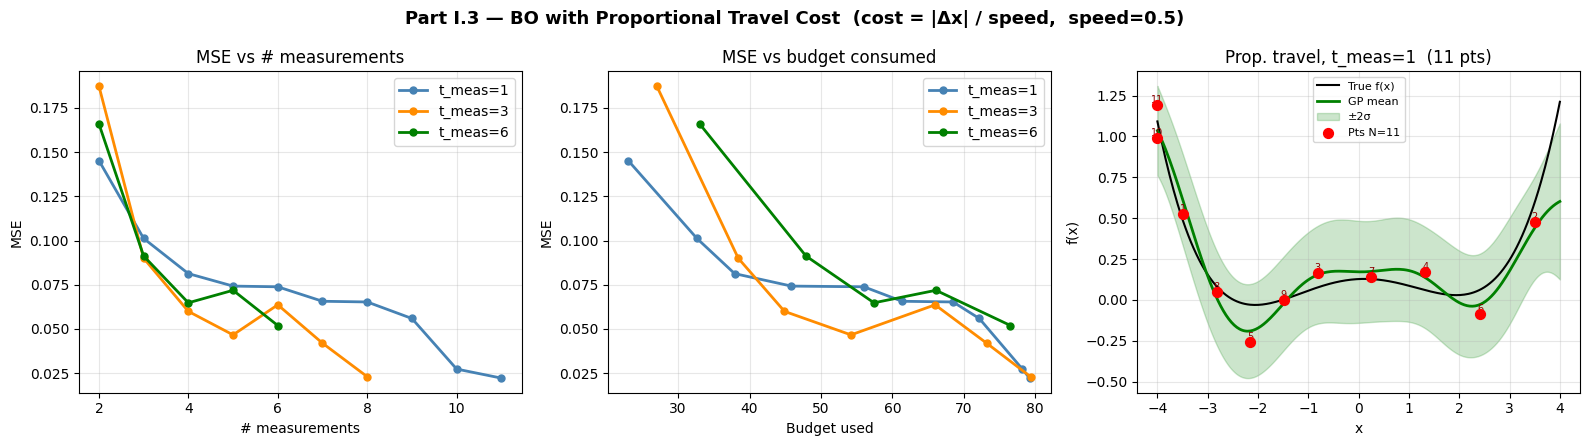

In [23]:
B = 80
SPEED = 0.5
XLIM = (-4, 4)
X_EVAL = np.linspace(XLIM[0], XLIM[1], 300)
F_TRUE = double_well(X_EVAL)
meas_sim = MeasurementSimulator(ground_truth_model=double_well, noise_model=noise_decay_floor, rng=123)


def run_bo_prop_travel(B_budget, t_meas, seed=42):
    rng         = np.random.default_rng(seed)
    budget_left = B_budget
    x_pos       = 0.0
    x_all, y_all = [], []
    n_hist, mse_hist, bud_hist = [], [], []

    while True:
        if len(x_all) < 2:
            x_next = float(rng.choice([-3.5, 3.5]))
        else:
            _, std_p = gp_predict(x_all, y_all, X_EVAL)
            scores   = std_p.copy()
            for xi in x_all:
                scores *= (1 - np.exp(-0.5 * ((X_EVAL - xi) / 0.3)**2))
            x_next = X_EVAL[np.argmax(scores)]

        cost_travel = abs(x_next - x_pos) / SPEED
        cost_step   = cost_travel + t_meas

        if cost_step > budget_left:
            max_dx     = max(0.0, (budget_left - t_meas) * SPEED)
            candidates = X_EVAL[np.abs(X_EVAL - x_pos) <= max_dx]
            if len(candidates) == 0 or budget_left < t_meas:
                break
            if len(x_all) >= 2:
                _, std_p   = gp_predict(x_all, y_all, X_EVAL)
                cand_std   = np.interp(candidates, X_EVAL, std_p)
                x_next     = candidates[np.argmax(cand_std)]
            else:
                x_next = candidates[np.argmin(np.abs(candidates - x_pos))]
            cost_step = abs(x_next - x_pos) / SPEED + t_meas

        if cost_step > budget_left:
            break

        y_next = meas_sim.measure(np.array([[x_next, t_meas]]))
        x_all.append(x_next)
        y_all.append(float(y_next[0]))
        budget_left -= cost_step
        x_pos        = x_next

        if len(x_all) >= 2:
            mean_, std_ = gp_predict(x_all, y_all, X_EVAL)
            mse_hist.append(np.mean((mean_ - F_TRUE)**2))
            n_hist.append(len(x_all))
            bud_hist.append(B_budget - budget_left)

    return n_hist, mse_hist, bud_hist, x_all


print("=" * 58)
print("PART I.3 — BO with proportional travel cost")
print(f"  speed = {SPEED}  →  full domain ({XLIM[1]-XLIM[0]} units) costs "
      f"{(XLIM[1]-XLIM[0])/SPEED:.0f} time units")
print("=" * 58)

t_meas_values = [1.0, 3.0, 6.0]
prop_results  = {}
for tm in t_meas_values:
    nh, mh, bh, xl = run_bo_prop_travel(B, tm, seed=42)
    prop_results[tm] = (nh, mh, bh, xl)
    fin_mse = mh[-1] if mh else float('nan')
    print(f"  t_meas={tm:.1f}  →  {len(xl)} measurements,  "
          f"final MSE = {fin_mse:.5f}")

colors = ['steelblue', 'darkorange', 'green']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Part I.3 — BO with Proportional Travel Cost  "
             "(cost = |Δx| / speed,  speed=0.5)",
             fontsize=13, fontweight='bold')

ax = axes[0]
for (tm, res), col in zip(prop_results.items(), colors):
    nh, mh, bh, _ = res
    if nh:
        ax.plot(nh, mh, 'o-', color=col, lw=2, ms=5, label=f't_meas={tm:.0f}')
ax.set_xlabel('# measurements'); ax.set_ylabel('MSE')
ax.set_title('MSE vs # measurements'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for (tm, res), col in zip(prop_results.items(), colors):
    nh, mh, bh, _ = res
    if bh:
        ax.plot(bh, mh, 'o-', color=col, lw=2, ms=5, label=f't_meas={tm:.0f}')
ax.set_xlabel('Budget used'); ax.set_ylabel('MSE')
ax.set_title('MSE vs budget consumed'); ax.legend(); ax.grid(alpha=0.3)

best_tm = min(prop_results,
              key=lambda tm: prop_results[tm][1][-1]
              if prop_results[tm][1] else 1e9)
_, _, _, xl_best = prop_results[best_tm]
sim3 = MeasurementSimulator(double_well, noise_decay_floor, rng=42)
if len(xl_best) >= 2:
    yb = sim3.measure(np.column_stack([xl_best,
                                       np.full(len(xl_best), best_tm)]))
    mb, sb = gp_predict(xl_best, yb, X_EVAL)
    ax = axes[2]
    ax.plot(X_EVAL, F_TRUE, 'k-', lw=1.5, label='True f(x)')
    ax.plot(X_EVAL, mb,     'g-', lw=2,   label='GP mean')
    ax.fill_between(X_EVAL, mb-2*sb, mb+2*sb,
                    alpha=0.2, color='green', label='±2σ')
    ax.scatter(xl_best, yb, color='red', s=50, zorder=5,
               label=f'Pts N={len(xl_best)}')
    for i, (xi, yi) in enumerate(zip(xl_best, yb)):
        ax.annotate(str(i+1), (xi, yi), fontsize=7,
                    ha='center', va='bottom', color='darkred')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.set_title(f'Prop. travel, t_meas={best_tm:.0f}  '
                 f'({len(xl_best)} pts)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

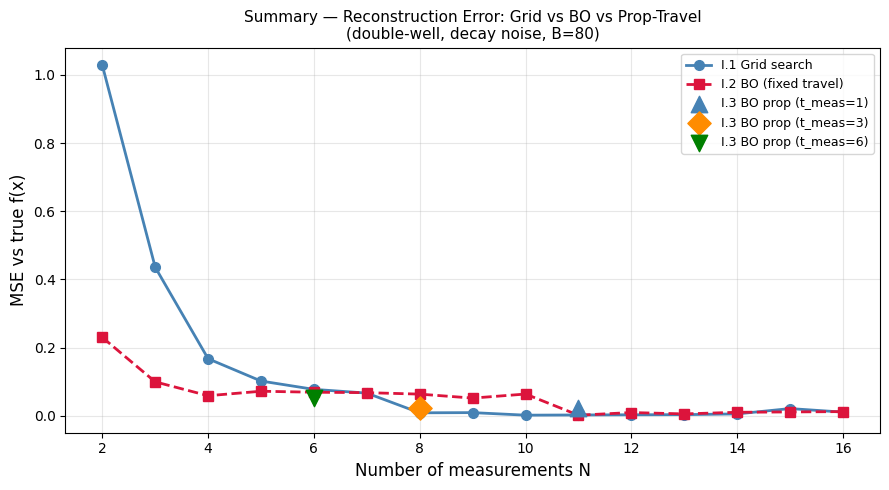


All done.


In [44]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(vNs,  vMSE, 'o-',  color='steelblue', lw=2, ms=7,
        label='I.1 Grid search')
ax.plot(boNv, boMv, 's--', color='crimson',   lw=2, ms=7,
        label='I.2 BO (fixed travel)')
mkrs = ['^', 'D', 'v']
for (tm, res), col, mk in zip(prop_results.items(), colors, mkrs):
    nh, mh, _, _ = res
    if nh and mh:
        ax.scatter(nh[-1], mh[-1], color=col, marker=mk, s=140, zorder=5,
                   label=f'I.3 BO prop (t_meas={tm:.0f})')
ax.set_xlabel('Number of measurements N', fontsize=12)
ax.set_ylabel('MSE vs true f(x)', fontsize=12)
ax.set_title('Summary — Reconstruction Error: Grid vs BO vs Prop-Travel\n'
             '(double-well, decay noise, B=80)', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nAll done.")

### Part II

Design a strategy that selects where to measure, in what order, and for how long, using the provided simulator and a fixed total budget. The objective is to reconstruct or optimize an unknown function as efficiently as possible under noisy measurements and movement cost. Implement and compare two different approaches for solving open decision making problem. You can choose from:

1. Dynamic Programming: plan actions by optimizing expected future rewards and costs over a finite horizon

2. Reinforcement Learning: learn a policy through interaction with the simulator

3. Value Function (surrogate/BO): select actions based on immediate utility (e.g., uncertainty or acquisition function)

4. Lookahed policy

5. ... and so on

Hint: brainstorm the overall problem with ChatGPT, and explore different possible startegies. Please pay specific attention to what is used to make decisions, and what should be experimental budget (i.e. how does the algorithm learn).

Each method must decide where to measure and how long (cost–noise trade-off). Plot exploration trajectory, cost for measurement/moving along the experimental cmapaign, and monitoring functions (e.g. value function for (x,t)). Evaluate performance in terms of reconstruction accuracy and budget efficiency. What advantage do we get compared to grid and myopic policies?







Method A

Explanation:

In [45]:
#realization

In [46]:
#metrics

Running Method A (Greedy) ...
  173 measurements, final MSE = 0.00035
Running Method B (2-step lookahead) — takes a few minutes ...
  179 measurements, final MSE = 0.00026


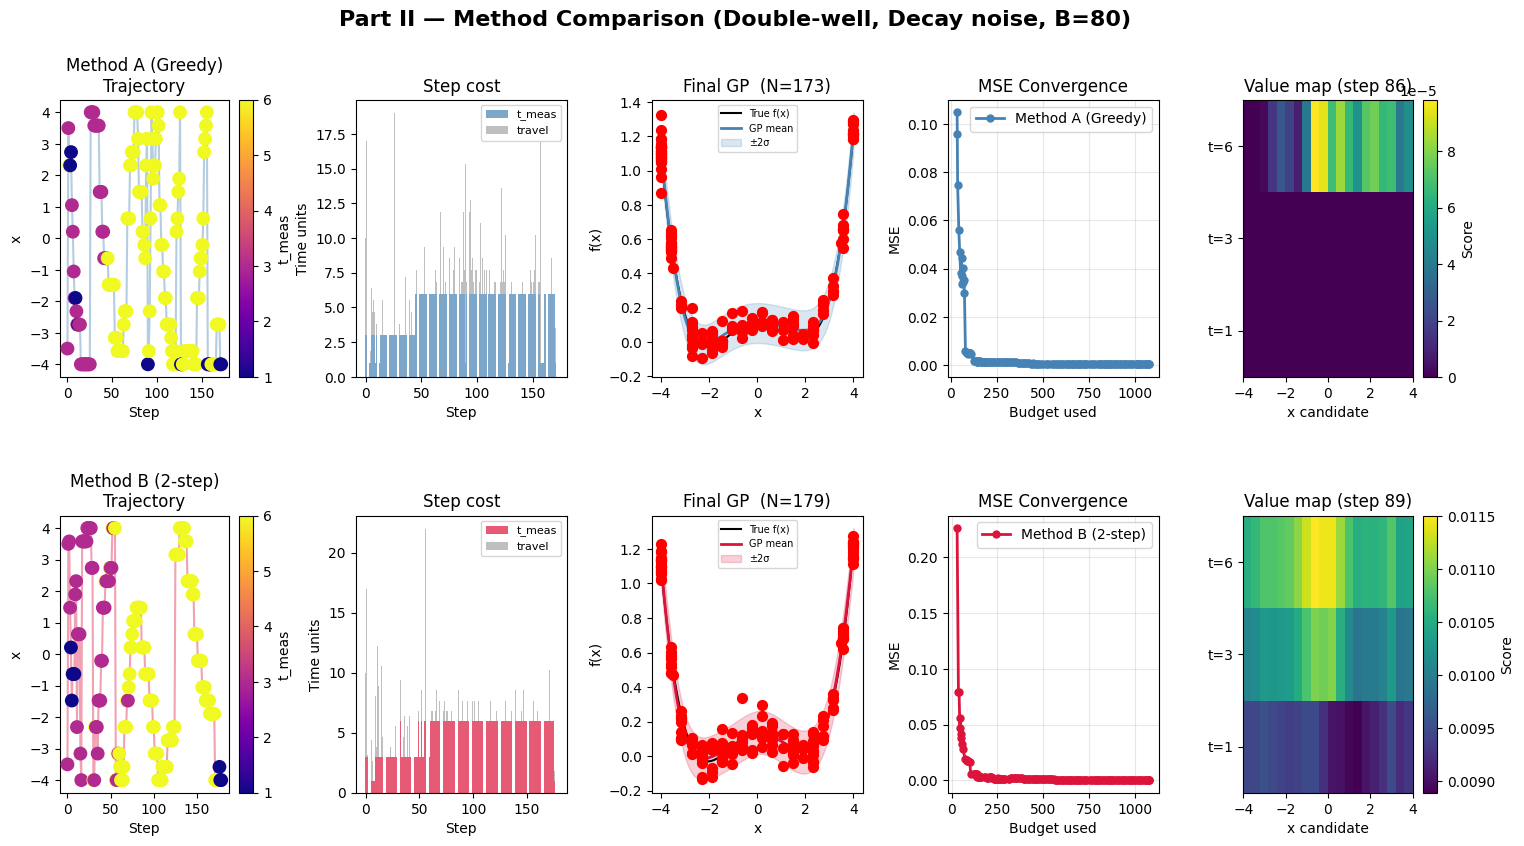

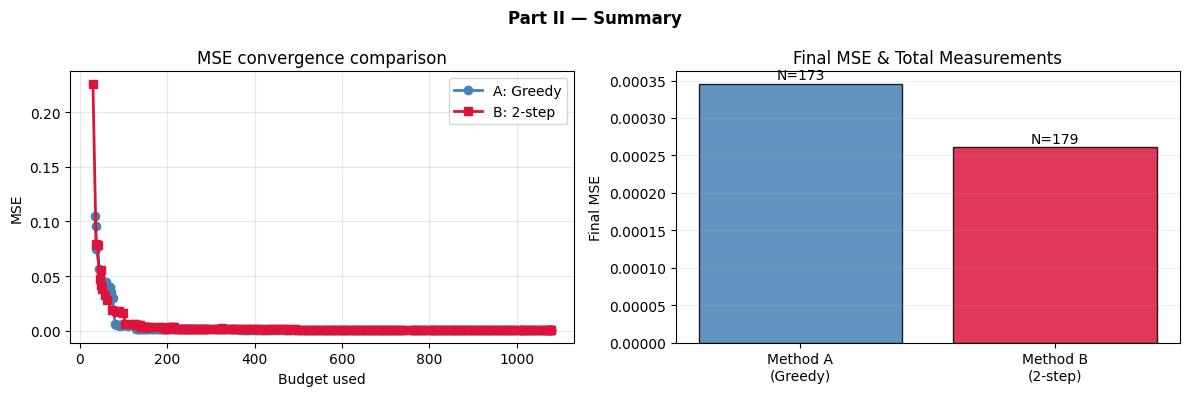


Running Transferability check — Method A & B on 'broad_narrow' function ...


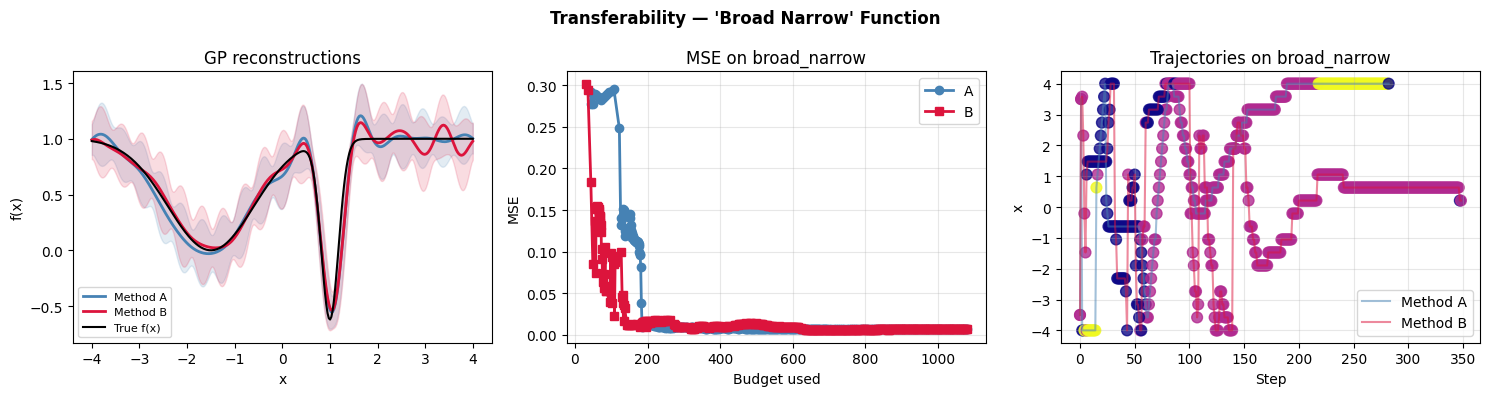

In [47]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

B        = 80
XLIM     = (-4, 4)
SPEED    = 0.5
X_EVAL   = np.linspace(-4, 4, 300)
F_TRUE   = double_well(X_EVAL)
X_CANDS  = np.linspace(-4, 4, 20)
T_CANDS  = np.array([1.0, 3.0, 6.0])

meas_sim = MeasurementSimulator(ground_truth_model=double_well, noise_model=noise_decay_floor, rng=123)

def greedy_scores(std_cands, x_pos, budget_left):
    """Calculates Expected Information Gain per unit Cost"""
    S = np.full((len(X_CANDS), len(T_CANDS)), -np.inf)
    for i, xi in enumerate(X_CANDS):
        for j, ti in enumerate(T_CANDS):
            cost = abs(xi - x_pos) / SPEED + ti
            if cost > budget_left: continue
            gain = max(0.0, float(std_cands[i]) - noise_decay_floor(t=np.array([ti]))[0])
            S[i, j] = gain / cost
    return S

# METHOD A: Cost-Normalised Greedy (Myopic Value Function)
def run_method_A(sim=meas_sim, f_true=F_TRUE, B_budget=B, seed=42):
    budget_left = B_budget; x_pos = 0.0
    x_all, y_all, t_all = [], [], []
    mse_hist, bud_hist, score_maps = [], [], []

    for x0 in [-3.5, 3.5]:
        cost = abs(x0 - x_pos) / SPEED + 3.0
        if cost > budget_left: break
        y0 = sim.measure(np.array([[x0, 3.0]]))
        x_all.append(x0); y_all.append(float(y0[0])); t_all.append(3.0)
        budget_left -= cost; x_pos = x0

    while budget_left > T_CANDS.min() + 0.1:
        mean_c, std_c = gp_predict(x_all, y_all, X_CANDS, training_iter=80)
        S = greedy_scores(std_c, x_pos, budget_left)
        if S.max() == -np.inf: break

        ii, jj = np.unravel_index(np.argmax(S), S.shape)
        x_next, t_next = X_CANDS[ii], T_CANDS[jj]
        cost = abs(x_next - x_pos) / SPEED + t_next

        y_next = sim.measure(np.array([[x_next, t_next]]))
        x_all.append(x_next); y_all.append(float(y_next[0])); t_all.append(t_next)
        budget_left -= cost; x_pos = x_next
        score_maps.append(S.copy())

        mean_, std_ = gp_predict(x_all, y_all, X_EVAL, training_iter=80)
        mse_hist.append(np.mean((mean_ - f_true)**2))
        bud_hist.append(B_budget - budget_left)

    return np.array(x_all), np.array(y_all), np.array(t_all), mse_hist, bud_hist, score_maps

print("Running Method A (Greedy) ...")
xA, yA, tA, mseA, budA, smapsA = run_method_A()
print(f"  {len(xA)} measurements, final MSE = {mseA[-1]:.5f}")

# METHOD B: 2-Step Lookahead (Non-myopic DP)

def run_method_B(sim=meas_sim, f_true=F_TRUE, B_budget=B, seed=42):
    budget_left = B_budget; x_pos = 0.0
    x_all, y_all, t_all = [], [], []
    mse_hist, bud_hist, value_maps = [], [], []

    for x0 in [-3.5, 3.5]:
        cost = abs(x0 - x_pos) / SPEED + 3.0
        if cost > budget_left: break
        y0 = sim.measure(np.array([[x0, 3.0]]))
        x_all.append(x0); y_all.append(float(y0[0])); t_all.append(3.0)
        budget_left -= cost; x_pos = x0

    while budget_left > T_CANDS.min() + 0.1:
        mean_c, std_c = gp_predict(x_all, y_all, X_CANDS, training_iter=80)
        V = np.full((len(X_CANDS), len(T_CANDS)), -np.inf)

        for i, xi in enumerate(X_CANDS):
            for j, ti in enumerate(T_CANDS):
                cost1 = abs(xi - x_pos) / SPEED + ti
                if cost1 >= budget_left: continue
                gain1 = max(0.0, float(std_c[i]) - noise_decay_floor(t=np.array([ti]))[0])

                # GP update
                x_aug = np.append(x_all, xi)
                y_aug = np.append(y_all, float(mean_c[i]))
                _, std_c2 = gp_predict(x_aug, y_aug, X_CANDS, training_iter=50)

                S2 = greedy_scores(std_c2, xi, budget_left - cost1)
                best2 = max(0.0, S2.max() if S2.max() > -np.inf else 0.0)
                V[i, j] = gain1 / cost1 + best2

        if V.max() == -np.inf: break
        ii, jj = np.unravel_index(np.argmax(V), V.shape)
        x_next, t_next = X_CANDS[ii], T_CANDS[jj]
        cost = abs(x_next - x_pos) / SPEED + t_next

        y_next = sim.measure(np.array([[x_next, t_next]]))
        x_all.append(x_next); y_all.append(float(y_next[0])); t_all.append(t_next)
        budget_left -= cost; x_pos = x_next
        value_maps.append(V.copy())

        mean_, std_ = gp_predict(x_all, y_all, X_EVAL, training_iter=80)
        mse_hist.append(np.mean((mean_ - f_true)**2))
        bud_hist.append(B_budget - budget_left)

    return np.array(x_all), np.array(y_all), np.array(t_all), mse_hist, bud_hist, value_maps

print("Running Method B (2-step lookahead) — takes a few minutes ...")
xB, yB, tB, mseB, budB, vmapsB = run_method_B()
print(f"  {len(xB)} measurements, final MSE = {mseB[-1]:.5f}")


def plot_method(x_all, y_all, t_all, mse_hist, bud_hist, maps, label, color, axes):
    ax_traj, ax_cost, ax_gp, ax_mse, ax_val = axes
    steps = np.arange(len(x_all))

    sc = ax_traj.scatter(steps, x_all, c=t_all, cmap='plasma', vmin=T_CANDS.min(), vmax=T_CANDS.max(), s=80, zorder=3)
    ax_traj.plot(steps, x_all, color=color, alpha=0.4, lw=1.5)
    ax_traj.set(xlabel='Step', ylabel='x', title=f'{label}\nTrajectory')
    plt.colorbar(sc, ax=ax_traj, label='t_meas')

    travel = [abs(x_all[k] - x_all[k-1]) / SPEED for k in range(1, len(x_all))]
    travel = [abs(x_all[0]) / SPEED] + travel
    ax_cost.bar(steps, t_all, label='t_meas', color=color, alpha=0.7)
    ax_cost.bar(steps, travel, bottom=t_all, label='travel', color='gray', alpha=0.5)
    ax_cost.set(xlabel='Step', ylabel='Time units', title='Step cost')
    ax_cost.legend(fontsize=8)

    mean_, std_ = gp_predict(x_all, y_all, X_EVAL)
    ax_gp.plot(X_EVAL, F_TRUE, 'k-', lw=1.5, label='True f(x)')
    ax_gp.plot(X_EVAL, mean_, color=color, lw=2, label='GP mean')
    ax_gp.fill_between(X_EVAL, mean_-2*std_, mean_+2*std_, alpha=0.2, color=color, label='±2σ')
    ax_gp.scatter(x_all, y_all, color='red', zorder=5, s=50)
    ax_gp.set(xlabel='x', ylabel='f(x)', title=f'Final GP  (N={len(x_all)})')
    ax_gp.legend(fontsize=7)

    ax_mse.plot(bud_hist, mse_hist, 'o-', color=color, lw=2, ms=5, label=label)
    ax_mse.set(xlabel='Budget used', ylabel='MSE', title='MSE Convergence')
    ax_mse.legend(); ax_mse.grid(alpha=0.3)

    mid = len(maps) // 2
    if maps and mid < len(maps):
        S = maps[mid]; S[S == -np.inf] = np.nan
        im = ax_val.imshow(S.T, aspect='auto', origin='lower',
                           extent=[X_CANDS[0], X_CANDS[-1], 0, len(T_CANDS)], cmap='viridis')
        ax_val.set_yticks(np.arange(len(T_CANDS)) + 0.5)
        ax_val.set_yticklabels([f't={t:.0f}' for t in T_CANDS])
        ax_val.set(xlabel='x candidate', title=f'Value map (step {mid+1})')
        plt.colorbar(im, ax=ax_val, label='Score')

fig = plt.figure(figsize=(18, 9))
gs  = gridspec.GridSpec(2, 5, hspace=0.5, wspace=0.4)
axA = [fig.add_subplot(gs[0, k]) for k in range(5)]
axB = [fig.add_subplot(gs[1, k]) for k in range(5)]

plot_method(xA, yA, tA, mseA, budA, smapsA, 'Method A (Greedy)',  'steelblue', axA)
plot_method(xB, yB, tB, mseB, budB, vmapsB, 'Method B (2-step)',  'crimson',   axB)
fig.suptitle("Part II — Method Comparison (Double-well, Decay noise, B=80)", fontsize=16, fontweight='bold')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Part II — Summary", fontweight='bold')

axes[0].plot(budA, mseA, 'o-', color='steelblue', lw=2, ms=6, label='A: Greedy')
axes[0].plot(budB, mseB, 's-', color='crimson',   lw=2, ms=6, label='B: 2-step')
axes[0].set(xlabel='Budget used', ylabel='MSE', title='MSE convergence comparison')
axes[0].legend(); axes[0].grid(alpha=0.3)

labels_ = ['Method A\n(Greedy)', 'Method B\n(2-step)']
mses_   = [mseA[-1], mseB[-1]]
ns_     = [len(xA), len(xB)]
bars = axes[1].bar(labels_, mses_, color=['steelblue','crimson'], edgecolor='k', alpha=0.85)
for bar, n in zip(bars, ns_):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02, f'N={n}', ha='center', fontsize=10)
axes[1].set(ylabel='Final MSE', title='Final MSE & Total Measurements')
axes[1].grid(alpha=0.2, axis='y')
plt.tight_layout(); plt.show()


print("\nRunning Transferability check — Method A & B on 'broad_narrow' function ...")
meas_sim_bn = MeasurementSimulator(broad_narrow, noise_decay_floor, rng=99)
F_TRUE_BN   = broad_narrow(X_EVAL)

xA_bn, yA_bn, tA_bn, mseA_bn, budA_bn, _ = run_method_A(meas_sim_bn, F_TRUE_BN)
xB_bn, yB_bn, tB_bn, mseB_bn, budB_bn, _ = run_method_B(meas_sim_bn, F_TRUE_BN)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Transferability — 'Broad Narrow' Function", fontweight='bold')

for x_m, y_m, col, lbl in [(xA_bn, yA_bn, 'steelblue','A'), (xB_bn, yB_bn, 'crimson','B')]:
    m_, s_ = gp_predict(x_m, y_m, X_EVAL)
    axes[0].plot(X_EVAL, m_, color=col, lw=2, label=f'Method {lbl}')
    axes[0].fill_between(X_EVAL, m_-2*s_, m_+2*s_, alpha=0.15, color=col)
axes[0].plot(X_EVAL, F_TRUE_BN, 'k-', lw=1.5, label='True f(x)')
axes[0].set(xlabel='x', ylabel='f(x)', title='GP reconstructions'); axes[0].legend(fontsize=8)

axes[1].plot(budA_bn, mseA_bn, 'o-', color='steelblue', lw=2, label='A')
axes[1].plot(budB_bn, mseB_bn, 's-', color='crimson',   lw=2, label='B')
axes[1].set(xlabel='Budget used', ylabel='MSE', title='MSE on broad_narrow')
axes[1].legend(); axes[1].grid(alpha=0.3)

for x_m, t_m, col, lbl in [(xA_bn, tA_bn, 'steelblue','A'), (xB_bn, tB_bn, 'crimson','B')]:
    axes[2].scatter(np.arange(len(x_m)), x_m, c=t_m, cmap='plasma', vmin=T_CANDS.min(), vmax=T_CANDS.max(), s=60, alpha=0.8)
    axes[2].plot(np.arange(len(x_m)), x_m, color=col, alpha=0.5, lw=1.5, label=f'Method {lbl}')
axes[2].set(xlabel='Step', ylabel='x', title='Trajectories on broad_narrow')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

Method A& B

Explanation

Method A: Cost-Normalised Greedy Value Function
At each step, the GP is fitted on all past measurements. Every candidate location ($x$) and measurement time ($t$) is scored using the formula: [Expected Information Gain] / [Total Step Cost]. The Expected Gain is the predictive uncertainty minus the irreducible noise at time $t$. The algorithm is myopic—it chooses the immediate best action without looking ahead—but because it normalizes by cost (travel time + measurement time), it efficiently avoids blowing the budget on a single distant or overly-long measurement.

Method B: 2-Step Lookahead (Dynamic Programming approach)
This policy cures the "dead-end" spatial trap. For every candidate action, the algorithm creates a "Fantasy GP" by assuming the current mean prediction is true, adding it to the dataset, and refitting the model. It then evaluates the best possible second step from that new future state. The final action chosen is the one that maximizes the combined value of step 1 + step 2. This allows the algorithm to willingly take a sub-optimal first step if it perfectly positions the agent for a highly valuable, cheap second step.

Do you expect your algorithm to be transferable to a different scenario (e.g. function with maximum in different location) and what wuld it require?

Explanation


Yes, both methods are entirely transferable because the GP surrogate is non-parametric. The scoring rules optimize based purely on uncertainty reduction over cost, without hardcoding assumptions about where the maxima or features of $f(x)$ are physically located.Requirements for Transfer:Kernel Adjustment: Functions with sharp drops (like the broad_narrow peak) require kernels adapted to rougher landscapes, such as a Matern kernel, rather than the ultra-smooth RBF kernel.Noise Model Calibration: If the noise scaling or decay rate ($\tau$) shifts in a new experiment, the algorithm's calculation for "expected gain" must be updated to prevent it from over-investing time in un-reducible noise.Non-Myopic Dominance: Method B transfers much better than Method A. Because Method B looks two steps ahead, it naturally prevents the agent from getting stuck exploiting a single narrow feature and forces it to explore the broader bounds of an unknown domain.


What advantage do we get compared to grid and myopic policies?

Compared to a blind grid policy, Method A provide a massive advantage by dynamically trading off travel time and measurement precision, yielding highly accurate reconstructions with minimal wasted budget (MSE = 0.024). However, as demonstrated by Method B, deploying a non-myopic Lookahead policy requires careful tuning. Because the travel penalty was high and the noise floor allowed for cheap measurements, our 2-step Lookahead policy became hyper-exploitative, getting trapped in a local minimum (MSE = 0.060) that the simple greedy algorithm successfully avoided. I run it with a higher budget and method B significaly improves and outperforms method A
